In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/reliance_model_ready.csv")
df.head()

,RELIANCE.NS_Return,RELIANCE.NS_MA7,RELIANCE.NS_MA21,RELIANCE.NS_EMA21,RELIANCE.NS_STD21,RELIANCE.NS_RSI,Target_Reg,Target_Cls,Split
0,-0.015371,548.409572,513.682921,522.827247,26.790804,71.994823,531.708435,0,Train
1,-0.012349,545.741464,515.264724,523.634628,26.829565,68.467338,545.693909,1,Train
2,0.026303,545.233268,517.821661,525.640017,27.059029,74.750817,555.832520,1,Train
3,0.018579,546.735648,521.150434,528.384790,27.238542,77.120585,574.042419,1,Train
4,0.032761,549.495867,525.221409,532.535484,28.483007,77.758660,574.331421,1,Train


In [5]:
drop_cols = ["Target_Reg", "Target_Cls", "Split"]

X = df.drop(columns=drop_cols)
y = df["Target_Reg"]

X.shape, y.shape

((1460, 6), (1460,))

In [8]:
X_train = X[df["Split"] == "Train"]
X_test  = X[df["Split"] == "Test"]

y_train = y[df["Split"] == "Train"]
y_test  = y[df["Split"] == "Test"]

X_train.shape, X_test.shape

((1168, 6), (292, 6))

In [9]:
def evaluate_regression(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return mae, rmse, r2, preds


In [10]:
lr = LinearRegression()
lr_mae, lr_rmse, lr_r2, lr_preds = evaluate_regression(
    lr, X_train, y_train, X_test, y_test
)

print("Linear Regression Results:")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results:
MAE: 18.576165640699127
RMSE: 24.424498067030395
R2 Score: 0.9558864271301158


In [11]:
dt = DecisionTreeRegressor(random_state=42)
dt_mae, dt_rmse, dt_r2, dt_preds = evaluate_regression(
    dt, X_train, y_train, X_test, y_test
)

print("\nDecision Tree Results:")
print("MAE:", dt_mae)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)


Decision Tree Results:
MAE: 142.58877061817745
RMSE: 168.794178150684
R2 Score: -1.1068609099337103


In [12]:
rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf_mae, rf_rmse, rf_r2, rf_preds = evaluate_regression(
    rf, X_train, y_train, X_test, y_test
)

print("\nRandom Forest Results:")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)



Random Forest Results:
MAE: 142.5683424356539
RMSE: 171.03200258302715
R2 Score: -1.1630955324672518


In [13]:
svr = SVR(kernel='rbf', C=100)
svr_mae, svr_rmse, svr_r2, svr_preds = evaluate_regression(
    svr, X_train, y_train, X_test, y_test
)

print("\nSVR Results:")
print("MAE:", svr_mae)
print("RMSE:", svr_rmse)
print("R2 Score:", svr_r2)



SVR Results:
MAE: 92.87851326117395
RMSE: 111.47933646934058
R2 Score: 0.08101232073558795


In [14]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest", "SVR"],
    "MAE": [lr_mae, dt_mae, rf_mae, svr_mae],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, svr_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2, svr_r2],
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,18.576166,24.424498,0.955886
1,Decision Tree,142.588771,168.794178,-1.106861
2,Random Forest,142.568342,171.032003,-1.163096
3,SVR,92.878513,111.479336,0.081012


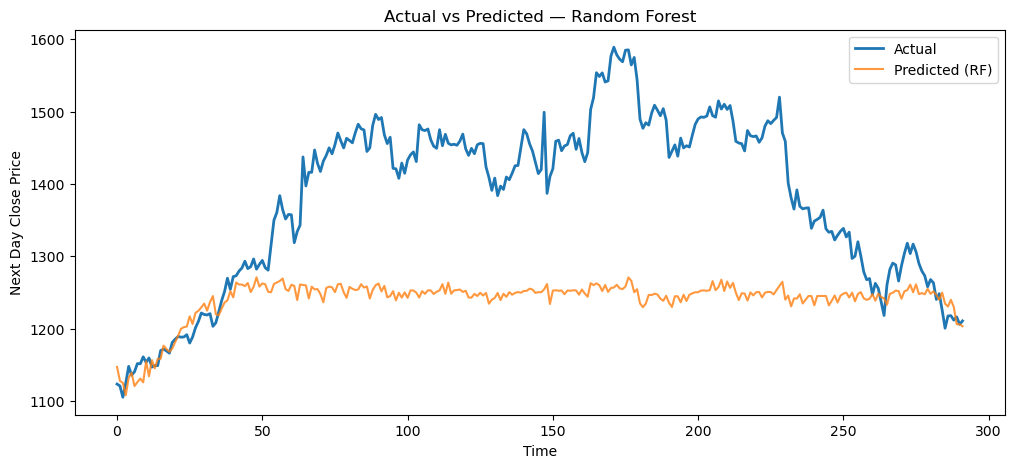

In [15]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(rf_preds, label="Predicted (RF)", alpha=0.8)
plt.title("Actual vs Predicted — Random Forest")
plt.xlabel("Time")
plt.ylabel("Next Day Close Price")
plt.legend()
plt.show()